### Experiment Design
This study explores various approaches for **wave height forecasting over the next 12 hours**, considering different input configurations and forecasting strategies.

#### Input Configurations
- **Baseline**: Previous hour's wave height as a persistent estimate for all future hours
- **Case 1**: Past n-hour wind observations
- **Case 2**: Past n-hour wave heights
- **Case 3**: Past n-hour wind observations + Past n-hour wave heights
- **Case 4**: Past n-hour wind observations + Future 12-hour wind forecasts
- **Case 5**: Past n-hour wind observations + Future 12-hour wind forecasts + Past n-hour wave heights

#### Experiments
- **Experiment 1**: Direct forecast of wave height over the next 12 hours
- **Experiment 2**: Rolling forecast with hourly updates over the next 12 hours
- **Experiment 3**: Explore different data input window lengths on model performance
- **Experiment 4**: Explore impact of wind forecast uncertainty on model performance

#### Further Model Optimization
- **Hyperparameter Tuning**
- **Bidirectional LSTM**: Incorporates both past and future temporal dependencies to improve wave height forecast accuracy

In [1]:
import numpy as np
import matplotlib.pyplot as plt

lead_time = list(range(1, 13))

# Baseline
test_rmse_base = [0.235, 0.364, 0.464, 0.550, 0.623, 0.687, 0.745, 0.796, 0.841, 0.880, 0.914, 0.946]

# Experiment 1
train_rmse_1_1 = [0.623, 0.641, 0.664, 0.687, 0.710, 0.730, 0.749, 0.772, 0.789, 0.806, 0.823, 0.837]
test_rmse_1_1 = [0.383, 0.433, 0.490, 0.541, 0.588, 0.621, 0.654, 0.690, 0.716, 0.743, 0.767, 0.786]

train_rmse_1_2 = [0.338, 0.419, 0.488, 0.551, 0.603, 0.649, 0.687, 0.720, 0.748, 0.771, 0.791, 0.811]
test_rmse_1_2 = [0.243, 0.356, 0.441, 0.519, 0.581, 0.635, 0.681, 0.718, 0.748, 0.773, 0.794, 0.816]

train_rmse_1_3 = [0.337, 0.408, 0.473, 0.527, 0.576, 0.618, 0.655, 0.689, 0.717, 0.743, 0.764, 0.786]
test_rmse_1_3 = [0.237, 0.342, 0.425, 0.496, 0.556, 0.605, 0.650, 0.689, 0.720, 0.748, 0.770, 0.793]

train_rmse_1_4 = [0.442, 0.424, 0.413, 0.406, 0.402, 0.397, 0.399, 0.401, 0.408, 0.414, 0.426, 0.450]
test_rmse_1_4 = [0.339, 0.332, 0.336, 0.338, 0.337, 0.338, 0.325, 0.329, 0.321, 0.328, 0.326, 0.343]

train_rmse_1_5 = [0.348, 0.375, 0.408, 0.430, 0.451, 0.461, 0.472, 0.480, 0.489, 0.499, 0.506, 0.522]
test_rmse_1_5 = [0.217, 0.226, 0.246, 0.258, 0.266, 0.268, 0.268, 0.264, 0.270, 0.272, 0.276, 0.297]

# Experiment 2
test_rmse_2_1 = [0.471, 0.484, 0.509, 0.542, 0.578, 0.616, 0.652, 0.687, 0.722, 0.753, 0.782, 0.808]
test_rmse_2_2 = [0.328, 0.557, 0.751, 0.894, 0.971, 0.978, 0.954, 0.932, 0.923, 0.926, 0.932, 0.937]
test_rmse_2_3 = [0.332, 0.521, 0.625, 0.683, 0.712, 0.721, 0.737, 0.753, 0.770, 0.788, 0.805, 0.822]
test_rmse_2_4 = [0.572, 0.530, 0.492, 0.459, 0.436, 0.422, 0.420, 0.429, 0.450, 0.479, 0.515, 0.555]
test_rmse_2_5 = [0.473, 0.562, 0.560, 0.567, 0.560, 0.563, 0.586, 0.615, 0.658, 0.701, 0.716, 0.837]

# Experiment 3
test_rmse_3_1 = [0.193, 0.222, 0.244, 0.252, 0.266, 0.278, 0.288, 0.297, 0.286, 0.289, 0.287, 0.296]
test_rmse_3_2 = [0.184, 0.206, 0.223, 0.236, 0.242, 0.246, 0.252, 0.256, 0.257, 0.264, 0.265, 0.274]
test_rmse_3_3 = [0.177, 0.205, 0.225, 0.230, 0.236, 0.246, 0.249, 0.256, 0.246, 0.251, 0.249, 0.254]
test_rmse_3_4 = [0.225, 0.232, 0.248, 0.245, 0.257, 0.242, 0.240, 0.243, 0.244, 0.247, 0.249, 0.256]
test_rmse_3_5 = [0.208, 0.218, 0.224, 0.238, 0.238, 0.238, 0.243, 0.244, 0.250, 0.257, 0.252, 0.261]
test_rmse_3_6 = [0.202, 0.220, 0.228, 0.229, 0.235, 0.244, 0.246, 0.243, 0.244, 0.243, 0.250, 0.250]
test_rmse_3_7 = [0.180, 0.210, 0.225, 0.229, 0.234, 0.241, 0.247, 0.250, 0.248, 0.245, 0.247, 0.251]

# Experiment 4
test_rmse_4_1 = [0.186, 0.266, 0.363, 0.378, 0.334, 0.340, 0.348, 0.357, 0.410, 0.518, 0.508, 0.423]

# Model optimization
test_rmse_LSTM = [0.176, 0.206, 0.223, 0.235, 0.238, 0.241, 0.244, 0.248, 0.241, 0.235, 0.236, 0.247]
test_rmse_BiLSTM = [0.184, 0.207, 0.234, 0.240, 0.244, 0.262, 0.270, 0.269, 0.258, 0.260, 0.251, 0.255]
test_rmse_LSTM_noise = [0.195, 0.247, 0.308, 0.331, 0.336, 0.335, 0.339, 0.339, 0.369, 0.434, 0.465, 0.450]
test_rmse_BiLSTM_noise = [0.182, 0.228, 0.308, 0.330, 0.316, 0.321, 0.334, 0.344, 0.381, 0.503, 0.471, 0.407]

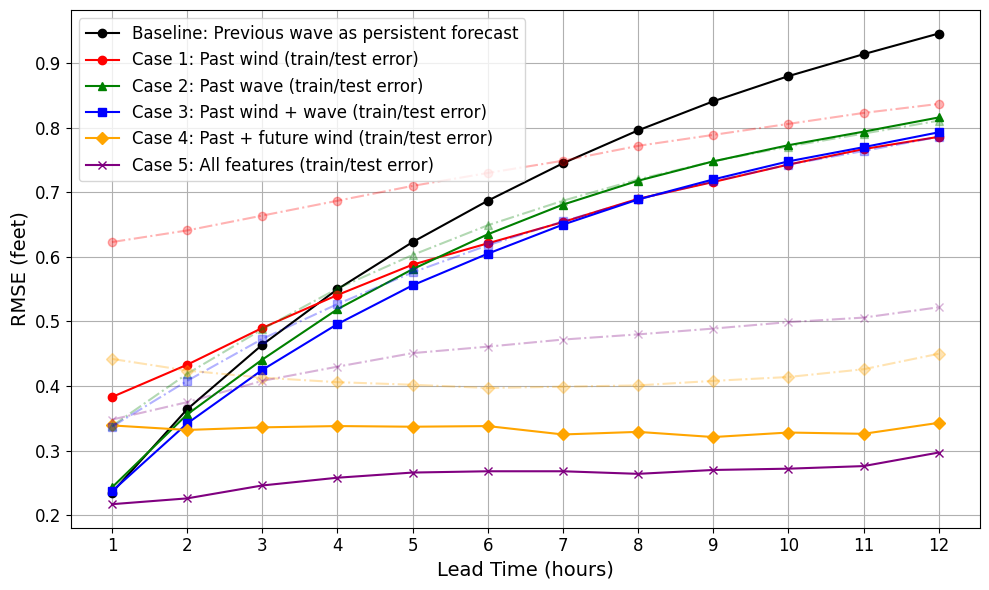

In [2]:
plt.figure(figsize=(10, 6))
plt.plot(lead_time, test_rmse_base, color='k', marker='o', label='Baseline: Previous wave as persistent forecast')

plt.plot(lead_time, test_rmse_1_1, color='r', marker='o', label='Case 1: Past wind (train/test error)')
plt.plot(lead_time, test_rmse_1_2, color='g', marker='^', label='Case 2: Past wave (train/test error)')
plt.plot(lead_time, test_rmse_1_3, color='b', marker='s', label='Case 3: Past wind + wave (train/test error)')
plt.plot(lead_time, test_rmse_1_4, color='orange', marker='D', label='Case 4: Past + future wind (train/test error)')
plt.plot(lead_time, test_rmse_1_5, color='purple', marker='x', label='Case 5: All features (train/test error)')

plt.plot(lead_time, train_rmse_1_1, color='r', linestyle='-.', marker='o', alpha=0.3)
plt.plot(lead_time, train_rmse_1_2, color='g', linestyle='-.', marker='^', alpha=0.3)
plt.plot(lead_time, train_rmse_1_3, color='b', linestyle='-.', marker='s', alpha=0.3)
plt.plot(lead_time, train_rmse_1_4, color='orange', linestyle='-.', marker='D', alpha=0.3)
plt.plot(lead_time, train_rmse_1_5, color='purple', linestyle='-.', marker='x', alpha=0.3)

plt.legend(fontsize=12)
plt.xticks(lead_time, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Lead Time (hours)', fontsize=14)
plt.ylabel('RMSE (feet)', fontsize=14)
plt.grid(True)
plt.tight_layout()
# plt.savefig('exp_1.png', dpi=1200, format='png')
plt.show()

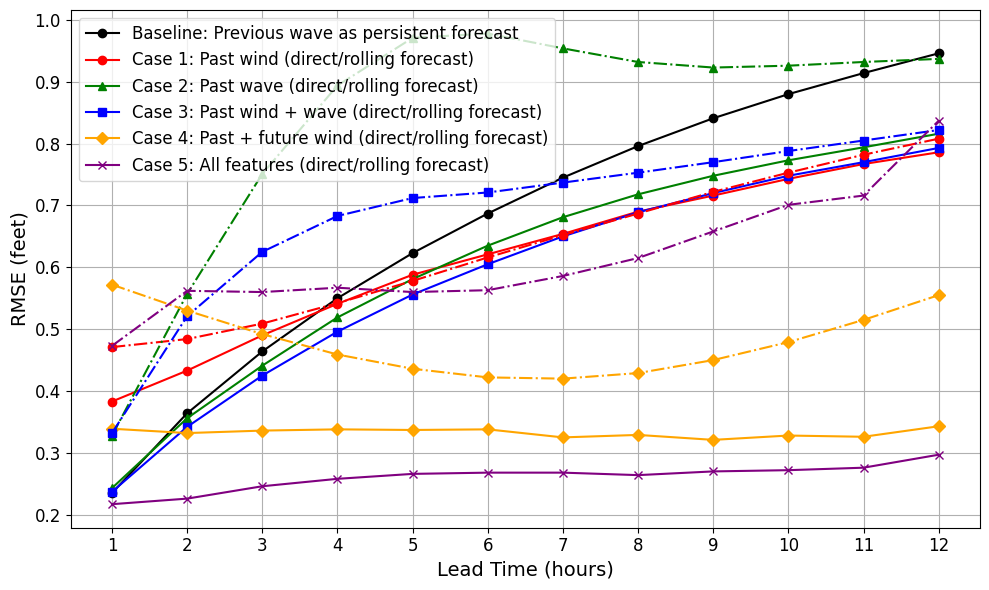

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(lead_time, test_rmse_base, color='k', marker='o', label='Baseline: Previous wave as persistent forecast')

plt.plot(lead_time, test_rmse_1_1, color='r', marker='o', label='Case 1: Past wind (direct/rolling forecast)')
plt.plot(lead_time, test_rmse_1_2, color='g', marker='^', label='Case 2: Past wave (direct/rolling forecast)')
plt.plot(lead_time, test_rmse_1_3, color='b', marker='s', label='Case 3: Past wind + wave (direct/rolling forecast)')
plt.plot(lead_time, test_rmse_1_4, color='orange', marker='D', label='Case 4: Past + future wind (direct/rolling forecast)')
plt.plot(lead_time, test_rmse_1_5, color='purple', marker='x', label='Case 5: All features (direct/rolling forecast)')

plt.plot(lead_time, test_rmse_2_1, color='r', linestyle='-.', marker='o')
plt.plot(lead_time, test_rmse_2_2, color='g', linestyle='-.', marker='^')
plt.plot(lead_time, test_rmse_2_3, color='b', linestyle='-.', marker='s')
plt.plot(lead_time, test_rmse_2_4, color='orange', linestyle='-.', marker='D')
plt.plot(lead_time, test_rmse_2_5, color='purple', linestyle='-.', marker='x')

plt.legend(fontsize=12)
plt.xticks(lead_time, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Lead Time (hours)', fontsize=14)
plt.ylabel('RMSE (feet)', fontsize=14)
plt.grid(True)
plt.tight_layout()
# plt.savefig('exp_2.png', dpi=1200, format='png')
plt.show()

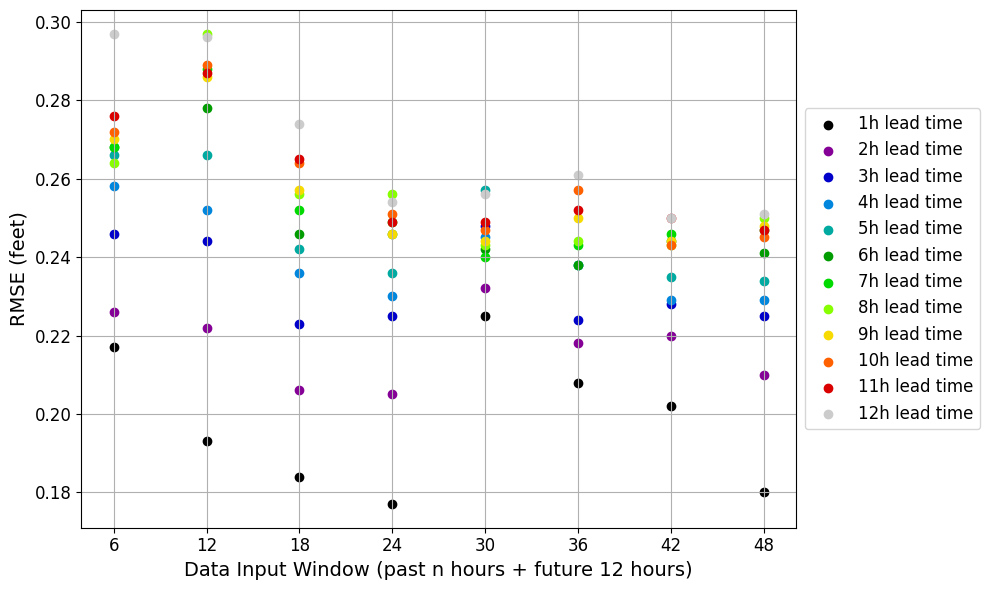

In [4]:
rmse_arr = np.array([test_rmse_1_5, test_rmse_3_1, test_rmse_3_2, test_rmse_3_3,
                     test_rmse_3_4, test_rmse_3_5, test_rmse_3_6, test_rmse_3_7])

plt.figure(figsize=(10, 6))
cmap = plt.get_cmap('nipy_spectral', 12)
colors = [cmap(i) for i in range(12)]
for i in range(12):
    plt.scatter(np.arange(6, 50, 6), rmse_arr[:, i], color=colors[i], marker='o', label=f'{i+1}h lead time')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.xticks(np.arange(6, 50, 6), fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Data Input Window (past n hours + future 12 hours)', fontsize=14)
plt.ylabel('RMSE (feet)', fontsize=14)
plt.grid(True)
plt.tight_layout()
# plt.savefig('exp_3.png', dpi=1200, format='png')
plt.show()

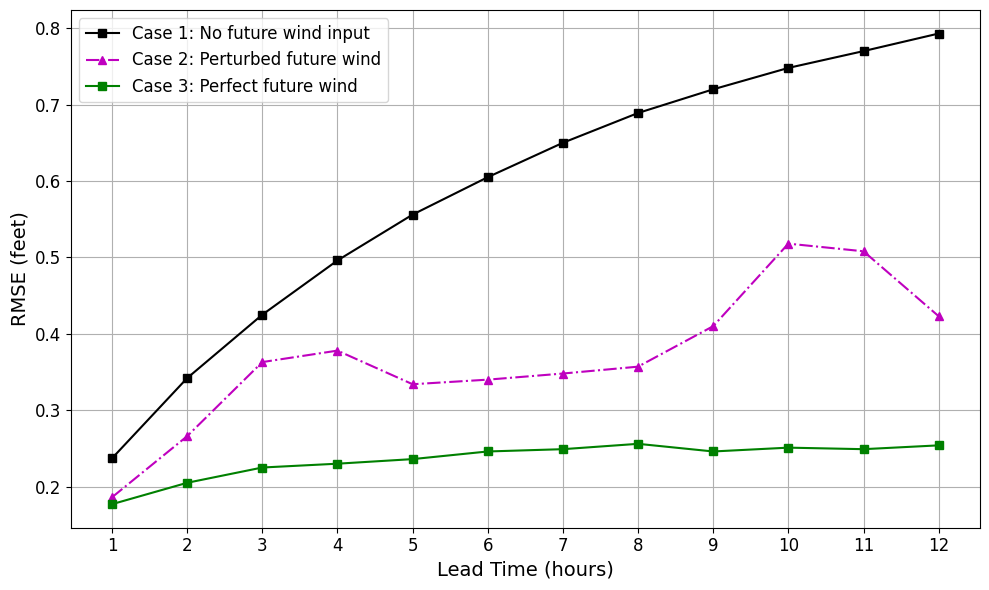

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(lead_time, test_rmse_1_3, color='k', marker='s', label='Case 1: No future wind input')
plt.plot(lead_time, test_rmse_4_1, color='m', marker='^', linestyle='-.', label='Case 2: Perturbed future wind')
plt.plot(lead_time, test_rmse_3_3, color='g', marker='s', label='Case 3: Perfect future wind')

plt.legend(fontsize=12)
plt.xticks(lead_time, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Lead Time (hours)', fontsize=14)
plt.ylabel('RMSE (feet)', fontsize=14)
plt.grid(True)
plt.tight_layout()
# plt.savefig('exp_4.png', dpi=1200, format='png')
plt.show()

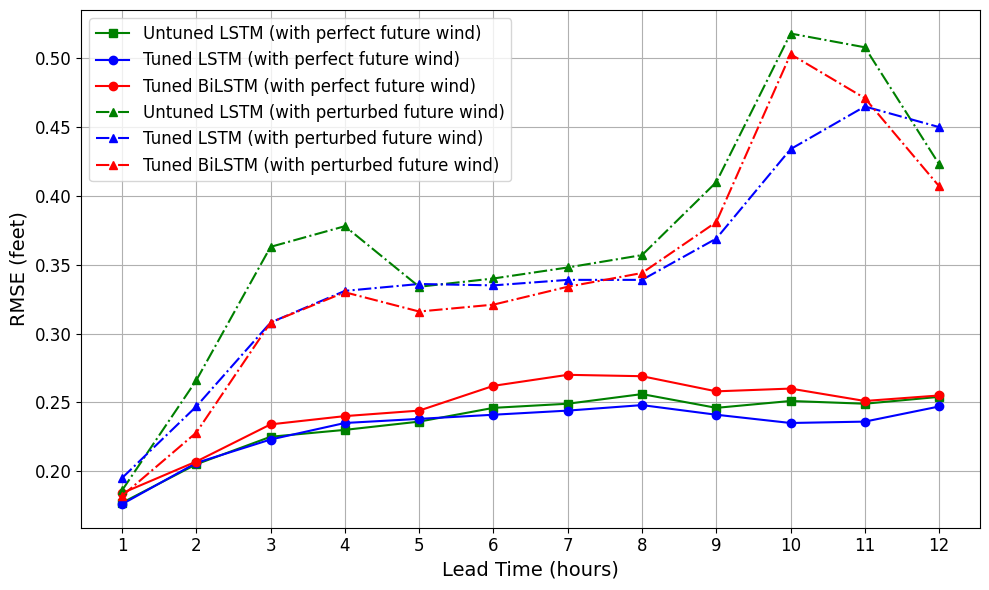

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(lead_time, test_rmse_3_3, color='g', marker='s', label='Untuned LSTM (with perfect future wind)')
plt.plot(lead_time, test_rmse_LSTM, color='b', marker='o', label='Tuned LSTM (with perfect future wind)')
plt.plot(lead_time, test_rmse_BiLSTM, color='r', marker='o', label='Tuned BiLSTM (with perfect future wind)')
plt.plot(lead_time, test_rmse_4_1, color='g', marker='^', linestyle='-.', label='Untuned LSTM (with perturbed future wind)')
plt.plot(lead_time, test_rmse_LSTM_noise, color='b', marker='^', linestyle='-.', label='Tuned LSTM (with perturbed future wind)')
plt.plot(lead_time, test_rmse_BiLSTM_noise, color='r', marker='^', linestyle='-.', label='Tuned BiLSTM (with perturbed future wind)')

plt.legend(fontsize=12)
plt.xticks(lead_time, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Lead Time (hours)', fontsize=14)
plt.ylabel('RMSE (feet)', fontsize=14)
plt.grid(True)
plt.tight_layout()
# plt.savefig('exp_opt.png', dpi=1200, format='png')
plt.show()